## Setup and Imports

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.utils import load_latest_dataset, print_dataset_schema

### Output files directories creation

In [20]:
artifacts_dir = Path("artifacts")

label_analysis_dir = artifacts_dir / "label_analysis"
label_analysis_dir.mkdir(parents=True, exist_ok=True)

## Data Loading and Validation

In [21]:
df, manifest, version_path = load_latest_dataset(data_dir="../data/processed")


Dataset loaded: 1475 records
  Version: 1.0.0
  Created: 2026-04-01T15:14:12.081301+00:00
  Git commit: 1dad8988


In [22]:
label_cols = [
    "has_pyproject_toml",
    "has_dockerfile",
    "has_github_actions",
    "has_tox_ini",
    "has_conda_env_file",
    "has_docker_compose",
    "has_precommit_config",
    "has_setup_py",
    "has_requirements_txt",
    "has_makefile",
]

schema = print_dataset_schema(df, label_cols)


id_col = schema["id_col"]
label_cols = schema["label_cols"]
feature_cols = schema["feature_cols"]

Dataset Schema:
  Total columns: 43
  Identifier: 1 (repo_url)
  Features: 32
  Labels: 10


### Detect nullable values

In [23]:
missing = df[feature_cols + label_cols].isnull().sum()

if missing.sum() > 0:
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame(
        {"Missing Count": missing, "Missing %": missing_pct}
    ).query("`Missing Count` > 0")
    print("Missing values detected:")
    print(missing_df)
else:
    print("No missing values")

No missing values


### Detect duplicates

In [24]:
duplicates = df[df.duplicated(subset=["repo_url"], keep=False)].sort_values("repo_url")

if not duplicates.empty:
    print(f"Found {len(duplicates)} duplicate entries based on repo_url:")
    print(duplicates[["repo_url"]].drop_duplicates())
else:
    print("No duplicate entries based on repo_url")

Found 988 duplicate entries based on repo_url:
                                               repo_url
0     https://github.com/0voice/interview_internal_r...
3                 https://github.com/0xAX/linux-insides
6                   https://github.com/1Panel-dev/MaxKB
8            https://github.com/2025Emma/vibe-coding-cn
10                    https://github.com/2noise/ChatTTS
...                                                 ...
1460                https://github.com/zai-org/CogVideo
1463            https://github.com/zai-org/Open-AutoGLM
1465              https://github.com/zauberzeug/nicegui
1467      https://github.com/zhayujie/chatgpt-on-wechat
1473            https://github.com/zylon-ai/private-gpt

[494 rows x 1 columns]


## Dataset presenting

In [25]:
print("Dataset sample:")
df.head()

Dataset sample:


,repo_url,stars,forks,repo_size_kb,open_issues_count,num_files,num_py_files,num_js_files,num_ts_files,num_html_files,...,has_pyproject_toml,has_dockerfile,has_github_actions,has_requirements_txt,has_conda_env_file,has_docker_compose,has_precommit_config,has_setup_py,has_tox_ini,has_makefile
0,https://github.com/0voice/interview_internal_r...,37216,9408,1161,36,163,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,https://github.com/0voice/interview_internal_r...,37216,9408,1161,36,163,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,https://github.com/0x4m4/hexstrike-ai,7813,1711,2131,72,13,2,0,0,0,...,False,False,False,True,False,False,False,False,False,False
3,https://github.com/0xAX/linux-insides,32266,3502,21356,34,144,2,0,0,0,...,False,True,True,False,False,False,False,False,False,True
4,https://github.com/0xAX/linux-insides,32266,3502,21356,34,144,2,0,0,0,...,False,True,True,False,False,False,False,False,False,True


### Descriptive Statistics

In [26]:
feature_stats = df[feature_cols].describe()

print("Feature Summary Statistics:")
feature_stats

Feature Summary Statistics:


,stars,forks,repo_size_kb,open_issues_count,num_files,num_py_files,num_js_files,num_ts_files,num_html_files,num_css_files,...,other_extensions_count,num_dirs,avg_files_per_dir,avg_py_file_len,avg_test_file_len,avg_nb_cell_count,avg_docs_file_len,num_dependencies,repo_age_days,recent_activity_days
count,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,...,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000
mean,24772.394576,3499.332881,70453.705085,313.400000,903.631864,276.501695,11.939661,32.260339,11.082034,2.931525,...,289.282712,179.312542,7.681586,246.047119,205.703390,5.836678,209.933017,49.926102,2195.130169,0.072542
std,33685.411253,5750.142406,100533.982239,592.420963,1751.097148,477.205199,80.492428,157.464170,71.054602,12.688473,...,1041.950789,448.507694,21.957680,383.770229,321.183741,31.517140,246.705172,141.618089,1662.306005,0.427385
min,6489.000000,16.000000,29.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.690000,0.000000,0.000000,0.000000,6.500000,0.000000,17.000000,0.000000
25%,10164.000000,1104.500000,7143.000000,50.000000,123.000000,33.000000,0.000000,0.000000,0.000000,0.000000,...,22.000000,20.000000,3.900000,130.750000,0.000000,0.000000,95.100000,5.000000,794.000000,0.000000
50%,15489.000000,1900.000000,30048.000000,142.000000,345.000000,100.000000,0.000000,0.000000,0.000000,0.000000,...,61.000000,57.000000,5.090000,192.500000,153.800000,0.000000,151.500000,17.000000,1814.000000,0.000000
75%,26385.000000,3456.000000,84681.500000,335.000000,953.500000,307.000000,4.000000,0.000000,3.000000,2.000000,...,186.000000,164.500000,7.130000,278.100000,291.000000,0.000000,225.700000,42.000000,3453.000000,0.000000
max,418016.000000,66067.000000,493928.000000,7924.000000,30687.000000,4968.000000,2266.000000,3056.000000,1730.000000,299.000000,...,24009.000000,5953.000000,606.250000,11379.500000,7043.000000,796.000000,2781.100000,2146.000000,6425.000000,8.000000


### Label frequency

Label Frequencies:
                      Count  Percentage
has_github_actions     1184        80.3
has_pyproject_toml      990        67.1
has_dockerfile          635        43.1
has_precommit_config    561        38.0
has_requirements_txt    524        35.5
has_setup_py            384        26.0
has_docker_compose      364        24.7
has_makefile            340        23.1
has_tox_ini             132         8.9
has_conda_env_file       79         5.4


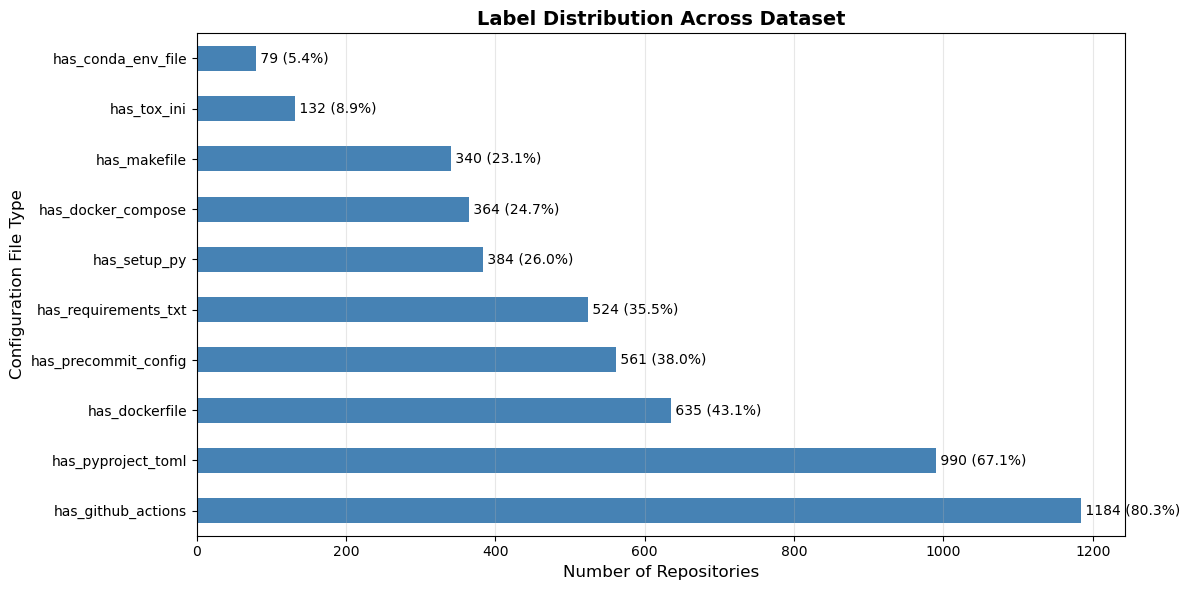

Exported: artifacts/label_analysis/label_frequencies.png


In [27]:
label_freq = df[label_cols].sum().sort_values(ascending=False)
label_freq_pct = (label_freq / len(df) * 100).round(1)

label_freq_df = pd.DataFrame({"Count": label_freq, "Percentage": label_freq_pct})

print("Label Frequencies:")
print(label_freq_df)

export_path = label_analysis_dir / "label_frequencies.png"

fig, ax = plt.subplots(figsize=(12, 6))
label_freq.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Number of Repositories", fontsize=12)
ax.set_ylabel("Configuration File Type", fontsize=12)
ax.set_title("Label Distribution Across Dataset", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

for i, (label, count) in enumerate(label_freq.items()):
    pct = label_freq_pct[label]
    ax.text(count, i, f" {count} ({pct}%)", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(export_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Exported: {export_path}")